# 02 — Lightcurve Extraction

## Objective

Retrieve STIX quick-look light curves for a selected flare, convert them into the
project's standardized DataFrame format, and extract the isolated flare window for
downstream characterization.

## Inputs

- Processed STIX flare catalog (`stix_flare_catalog_sep20_25_2021.csv`)
- STIX Data Center — via `stixdcpy`

## Outputs

- `lightcurve` — full parsed light curve DataFrame covering the fetched window
- `flare_window` — trimmed DataFrame restricted to the flare's catalog interval

## Scientific Milestone

Demonstrate the complete data pipeline for a single flare:
catalog entry → raw light curve → standardized DataFrame → isolated flare window.
This exact workflow will be applied to every flare during the full pipeline run.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from flare_pipeline.lightcurves import (
    get_lightcurve,
    parse_lightcurve,
    extract_flare_window,
)

## 1. Load Catalog

In [3]:
# Importing the catalog already prepared

flare_df = pd.read_csv(
    "../data/processed/stix_flare_catalog_sep20_25_2021.csv"
)

# flare_id round-trips through CSV as int64 — cast to str to match pipeline convention and converting the timestamps to date-time type
flare_df["flare_id"] = flare_df["flare_id"].astype(str)
flare_df["start_UTC"] = pd.to_datetime(flare_df["start_UTC"])
flare_df["end_UTC"]   = pd.to_datetime(flare_df["end_UTC"])
flare_df["peak_UTC"]  = pd.to_datetime(flare_df["peak_UTC"])

flare_df.head()

,flare_id,duration,att_in,peak_UTC,LC0_BKG,_id,GOES_class,GOES_flux,goes_estimated_min_class,goes_estimated_max_class,...,LC0_PEAK_COUNTS_4S,LC0_BKG_COUNTS_4S,LC1_PEAK_COUNTS_4S,LC1_BKG_COUNTS_4S,LC2_PEAK_COUNTS_4S,LC2_BKG_COUNTS_4S,LC3_PEAK_COUNTS_4S,LC3_BKG_COUNTS_4S,LC4_PEAK_COUNTS_4S,LC4_BKG_COUNTS_4S
0,2109252306,1412,False,2021-09-25 23:06:40.433,242.007612,3424,B5.0,5.004427e-07,B5,B10,...,1727,247.0,303,49.0,183,67.0,863,799.0,495,431.0
1,2109252204,216,False,2021-09-25 22:04:20.427,242.007612,3423,B2.1,2.060040e-07,B2,B4,...,431,247.0,67,49.0,99,67.0,863,799.0,495,431.0
2,2109252139,124,False,2021-09-25 21:39:28.431,242.007612,3422,B2.0,2.009259e-07,B2,B3,...,303,247.0,67,49.0,91,67.0,863,799.0,495,431.0
3,2109252113,140,False,2021-09-25 21:13:08.428,242.007612,3421,B2.2,2.213787e-07,B2,B4,...,399,247.0,83,49.0,91,67.0,863,799.0,463,431.0
4,2109252058,428,False,2021-09-25 20:58:36.420,242.007612,3420,B2.3,2.297031e-07,B2,B3,...,335,247.0,67,49.0,83,67.0,863,799.0,543,431.0


## 2. Select Test Flare

Row 50 is used as a representative test flare throughout pipeline development.
This is an arbitrary selection for single-flare validation — the same code
will iterate over all catalog rows during the full pipeline run.

In [4]:
flare_row = flare_df.loc[50]
flare_row[["flare_id", "start_UTC", "peak_UTC", "end_UTC", "GOES_class"]]

flare_id                      2109241944
start_UTC     2021-09-24 19:43:44.265000
peak_UTC      2021-09-24 19:44:24.265000
end_UTC       2021-09-24 19:46:36.265000
GOES_class                          B1.7
Name: 50, dtype: object

## 3. Fetch and Parse Light Curve

The fetch window extends 10 minutes beyond the catalog `start_UTC` and `end_UTC`.
This padding ensures the background estimation windows (5 min pre/post flare)
computed in the next notebook fall within the fetched data.

In [5]:
pad = pd.Timedelta(minutes=10)

lc = get_lightcurve(
    start_time=(flare_row["start_UTC"] - pad).isoformat(),
    end_time=(flare_row["end_UTC"] + pad).isoformat(),
)

lightcurve = parse_lightcurve(lc)
lightcurve

,time,4_10,10_15,15_25,25_50,50_84
0,2021-09-24 19:22:20,215,53,67,799,431
1,2021-09-24 19:22:24,247,53,67,863,431
2,2021-09-24 19:22:28,247,57,61,799,463
3,2021-09-24 19:22:32,271,41,61,863,431
4,2021-09-24 19:22:36,247,37,75,863,431
...,...,...,...,...,...,...
575,2021-09-24 20:00:40,215,45,61,863,431
576,2021-09-24 20:00:44,247,49,67,799,399
577,2021-09-24 20:00:48,247,45,57,799,463
578,2021-09-24 20:00:52,231,53,67,799,495


## 4. Extract Flare Window

Trim the full light curve to the catalog's `[start_UTC, end_UTC]` interval.
Only this window is passed to background subtraction, onset detection, and fluence
calculation. The 10-minute padding on either side remains in `lightcurve` for
background estimation but is not part of the flare window itself.

In [11]:
flare_window = extract_flare_window(
    lightcurve,
    flare_row["start_UTC"],
    flare_row["end_UTC"],
)

print(f"Full lightcurve : {len(lightcurve)} rows")
print(f"Flare window    : {len(flare_window)} rows")
print(f"Window span     : {flare_window['time'].iloc[0]}  →  {flare_window['time'].iloc[-1]}")

Full lightcurve : 580 rows
Flare window    : 43 rows
Window span     : 2021-09-24 19:43:48  →  2021-09-24 19:46:36


## 5. Visualize

SXR (4-10 keV) and HXR (15-25 keV) count flux over full fetched window.
The shaded region marks the catalog flare interval - the portion passed to downstream charaterization. For this weak B-class flare, SXR shows a clear rise and decay; HXR emission is marginal above background, which is physically expected for the events of this intensity.

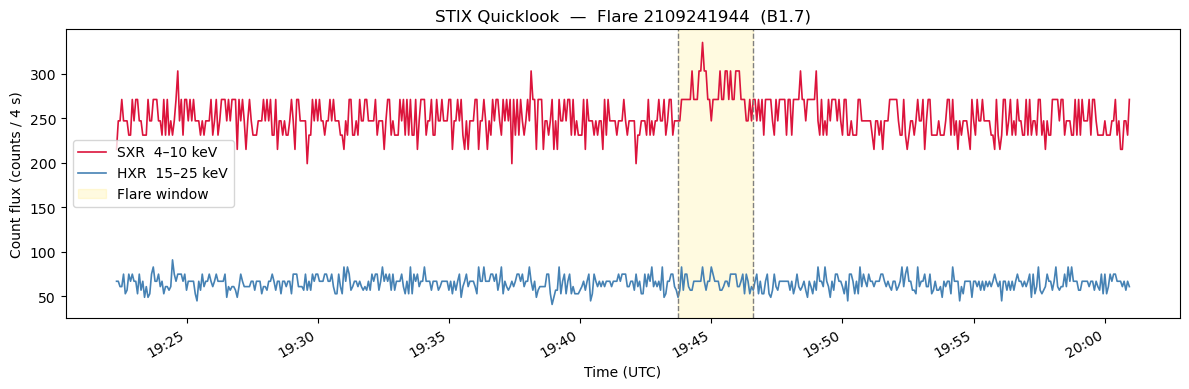

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(lightcurve["time"], lightcurve["4_10"],
        color="crimson", lw=1.2, label="SXR  4–10 keV")
ax.plot(lightcurve["time"], lightcurve["15_25"],
        color="steelblue", lw=1.2, label="HXR  15–25 keV")

# Shaded region = extracted flare window
ax.axvspan(
    flare_row["start_UTC"], flare_row["end_UTC"],
    alpha=0.12, color="gold", label="Flare window"
)

# Catalog boundary markers
ax.axvline(flare_row["start_UTC"], color="gray", lw=1, ls="--")
ax.axvline(flare_row["end_UTC"],   color="gray", lw=1, ls="--")

ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Count flux (counts / 4 s)")
ax.set_title(
    f"STIX Quicklook  —  Flare {flare_row['flare_id']}  ({flare_row['GOES_class']})"
)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()